# Exploratory Data Analysis (EDA) - Diabetic Dataset

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utility.main import read_data

%matplotlib inline
sns.set_theme(style="whitegrid")

In [3]:
df = read_data()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 1. Clean the Data

Replace '?' with NaN and check for duplicates.

In [4]:
# Replace '?' with np.nan
df.replace('?', np.nan, inplace=True)

# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Number of duplicate rows: 0
Shape after dropping duplicates: (101766, 50)


## 2. Handle Missing Values

Identify columns with high missingness and drop them, and handle rows with missing critical data.

In [5]:
# Summary of missing values
null_counts = df.isnull().sum()
null_percentages = 100 * null_counts / len(df)
missing_data = pd.concat([null_counts, null_percentages], axis=1, keys=['Total', 'Percent'])
missing_data[missing_data['Total'] > 0].sort_values(by='Percent', ascending=False)

,Total,Percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [6]:
# Drop columns with excessive missing values (>40%)
cols_to_drop = ['weight', 'payer_code', 'medical_specialty']
df.drop(columns=cols_to_drop, inplace=True)

# Drop rows with missing critical categorical values (race, diag_1, etc.) if they are few
df.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3', 'gender'], inplace=True)

print(f"Shape after handling missing values: {df.shape}")

Shape after handling missing values: (98053, 47)


## 3. Drop Null Columns

Check for any remaining columns that are entirely null (though usually handled above).

In [7]:
all_null_cols = df.columns[df.isnull().all()]
print(f"Columns with all null values: {list(all_null_cols)}")
df.drop(columns=all_null_cols, inplace=True)

Columns with all null values: []


## 4. Transform Data

Convert age to numerical and readmitted to categorical/binary.

In [8]:
# Transform 'age' range to the midpoint or lower bound
age_map = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, 
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, 
    '[80-90)': 8, '[90-100)': 9
}
df['age_numeric'] = df['age'].replace(age_map)

# Update target: 1 if readmitted < 30 days, 0 otherwise
df['target'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print('Target and Age transformations complete.')
df[['age', 'age_numeric', 'readmitted', 'target']].head()

Target and Age transformations complete.


/tmp/ipykernel_669130/1502472830.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['age_numeric'] = df['age'].replace(age_map)


,age,age_numeric,readmitted,target
1,[10-20),1,>30,0
2,[20-30),2,NO,0
3,[30-40),3,NO,0
4,[40-50),4,NO,0
5,[50-60),5,>30,0


### 4.1 Target Encoding with Smoothing

Encode diagnosis columns using smoothed target encoding to handle high cardinality and mitigate overfitting.

In [9]:
def smoothed_target_encoding(df, column, target, m=10):
    """
    Computes smoothed target encoding for a categorical column.
    Formula: (count * mean + m * global_mean) / (count + m)
    """
    global_mean = df[target].mean()
    
    # Group by the categorical column and calculate counts and means of the target
    agg = df.groupby(column)[target].agg(['count', 'mean'])
    
    # Compute the smoothed values
    smoothed = (agg['count'] * agg['mean'] + m * global_mean) / (agg['count'] + m)
    
    return df[column].map(smoothed)

# Apply smoothed target encoding to diagnosis columns
diag_cols = ['diag_1', 'diag_2', 'diag_3']
for col in diag_cols:
    # We overwrite the columns with their encoded numerical values as requested
    df[col] = smoothed_target_encoding(df, col, 'target', m=10)

print("Diagnosis columns have been target encoded with smoothing.")
df[diag_cols].head()

Diagnosis columns have been target encoded with smoothing.


,diag_1,diag_2,diag_3
1,0.136409,0.131066,0.216817
2,0.064636,0.076933,0.025649
3,0.133585,0.241926,0.163434
4,0.142372,0.141167,0.085232
5,0.091655,0.098216,0.085232


### 4.2 Numerical Imputation and Feature Encoding

Handle missing values in numerical columns and encode the remaining categorical features into numerical format.

In [10]:
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
# 1. Handle missing numerical values with average
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# 2. Binary mapping for simple categories
df['change'] = df['change'].replace({'No': 0, 'Ch': 1})
df['diabetesMed'] = df['diabetesMed'].replace({'No': 0, 'Yes': 1})

# 3. Gender mapping (removing Unknown/Invalid rows first)
df = df[df['gender'] != 'Unknown/Invalid']
df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})

# 4. Binary mapping for medications (No=0, Steady/Up/Down=1)
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]
for col in medication_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 0 if x == 'No' else 1)

# 5. One-hot encoding for Race
df = pd.get_dummies(df, columns=['race'], prefix='race', dtype=int)

print("Imputation and Encoding complete.")
print(f"Final dataframe shape: {df.shape}")
df.head()

/tmp/ipykernel_669130/2905668149.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['change'] = df['change'].replace({'No': 0, 'Ch': 1})
/tmp/ipykernel_669130/2905668149.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diabetesMed'] = df['diabetesMed'].replace({'No': 0, 'Yes': 1})
/tmp/ipykernel_669130/2905668149.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the fu

Imputation and Encoding complete.
Final dataframe shape: (98052, 53)


,encounter_id,patient_nbr,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,change,diabetesMed,readmitted,age_numeric,target,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other
1,149190,55629189,1,[10-20),1,1,7,3,59,0,...,1,1,0,1,0,0,0,1,0,0
2,64410,86047875,1,[20-30),1,1,7,2,11,5,...,0,1,0,2,0,1,0,0,0,0
3,500364,82442376,0,[30-40),1,1,7,2,44,1,...,1,1,0,3,0,0,0,1,0,0
4,16680,42519267,0,[40-50),1,1,7,1,51,0,...,1,1,0,4,0,0,0,1,0,0
5,35754,82637451,0,[50-60),2,1,2,3,31,6,...,0,1,0,5,0,0,0,1,0,0


In [11]:
df.shape

(98052, 53)

In [12]:
df.nunique()

encounter_id                98052
patient_nbr                 68629
gender                          2
age                            10
admission_type_id               8
discharge_disposition_id       26
admission_source_id            17
time_in_hospital               14
num_lab_procedures            118
num_procedures                  7
num_medications                75
number_outpatient              39
number_emergency               33
number_inpatient               20
diag_1                        347
diag_2                        324
diag_3                        329
number_diagnoses               14
max_glu_serum                   3
A1Cresult                       3
metformin                       2
repaglinide                     2
nateglinide                     2
chlorpropamide                  2
glimepiride                     2
acetohexamide                   2
glipizide                       2
glyburide                       2
tolbutamide                     2
pioglitazone  

## 5. Check for Uniqueness

Identify columns with only one unique value (constant columns) and check unique counts.

In [13]:
unique_counts = df.nunique().sort_values()
constant_cols = unique_counts[unique_counts == 1].index.tolist()
print(f"Constant columns (to drop): {constant_cols}")
df.drop(columns=constant_cols, inplace=True)

print("\nUnique counts for remaining 10 columns:")
print(unique_counts[unique_counts > 1].head(10))

Constant columns (to drop): ['citoglipton', 'metformin-rosiglitazone', 'examide']

Unique counts for remaining 10 columns:
gender            2
acarbose          2
acetohexamide     2
glipizide         2
glyburide         2
glimepiride       2
repaglinide       2
nateglinide       2
chlorpropamide    2
metformin         2
dtype: int64


In [14]:
from pprint import pprint

string_uniques = {
    col: df[col].unique().tolist() 
    for col in df 
    if pd.api.types.is_string_dtype(df[col])
}
pprint(string_uniques)

{'age': ['[10-20)',
         '[20-30)',
         '[30-40)',
         '[40-50)',
         '[50-60)',
         '[60-70)',
         '[70-80)',
         '[80-90)',
         '[90-100)',
         '[0-10)']}


## 6. Statistical EDA

Descriptive statistics and visualizations.

In [15]:
print("Descriptive Statistics for Numerical Features:")
df.describe().T

Descriptive Statistics for Numerical Features:


,count,mean,std,min,25%,50%,75%,max
encounter_id,98052.0,1.658301e+08,1.024325e+08,12522.000000,8.528559e+07,1.533025e+08,2.305018e+08,4.438672e+08
patient_nbr,98052.0,5.484745e+07,3.866167e+07,135.000000,2.350234e+07,4.687610e+07,8.800306e+07,1.895026e+08
gender,98052.0,5.388263e-01,4.984928e-01,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
admission_type_id,98052.0,2.025803e+00,1.450121e+00,1.000000,1.000000e+00,1.000000e+00,3.000000e+00,8.000000e+00
discharge_disposition_id,98052.0,3.753396e+00,5.309412e+00,1.000000,1.000000e+00,1.000000e+00,4.000000e+00,2.800000e+01
admission_source_id,98052.0,5.776741e+00,4.071632e+00,1.000000,1.000000e+00,7.000000e+00,7.000000e+00,2.500000e+01
time_in_hospital,98052.0,4.422011e+00,2.993070e+00,1.000000,2.000000e+00,4.000000e+00,6.000000e+00,1.400000e+01
num_lab_procedures,98052.0,4.314846e+01,1.971176e+01,1.000000,3.100000e+01,4.400000e+01,5.700000e+01,1.320000e+02
num_procedures,98052.0,1.350712e+00,1.708475e+00,0.000000,0.000000e+00,1.000000e+00,2.000000e+00,6.000000e+00
num_medications,98052.0,1.611959e+01,8.108496e+00,1.000000,1.100000e+01,1.500000e+01,2.000000e+01,8.100000e+01


/tmp/ipykernel_669130/3690561469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=df, palette='viridis')


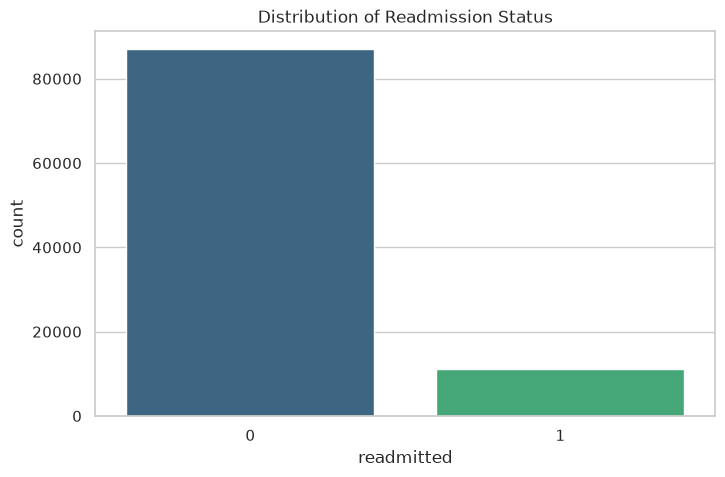

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='readmitted', data=df, palette='viridis')
plt.title('Distribution of Readmission Status')
plt.show()

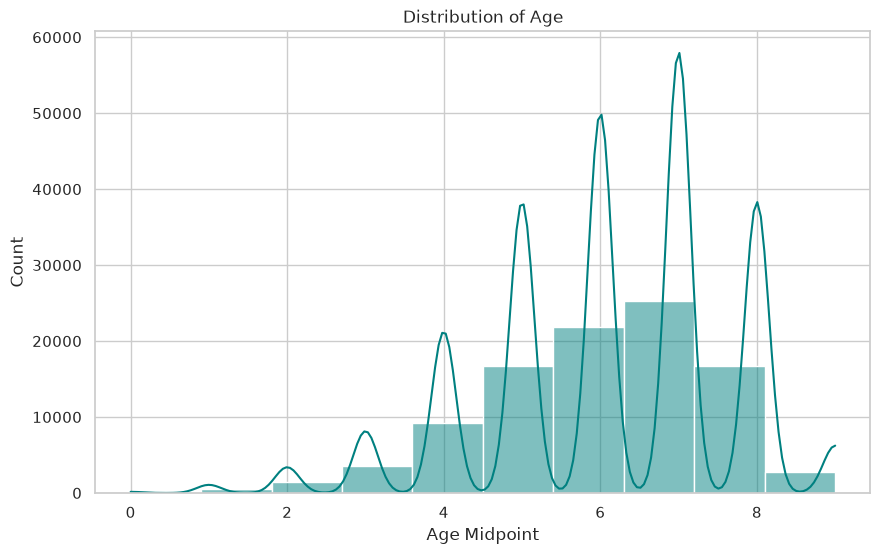

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age_numeric'], bins=10, kde=True, color='teal')
plt.title('Distribution of Age')
plt.xlabel('Age Midpoint')
plt.show()

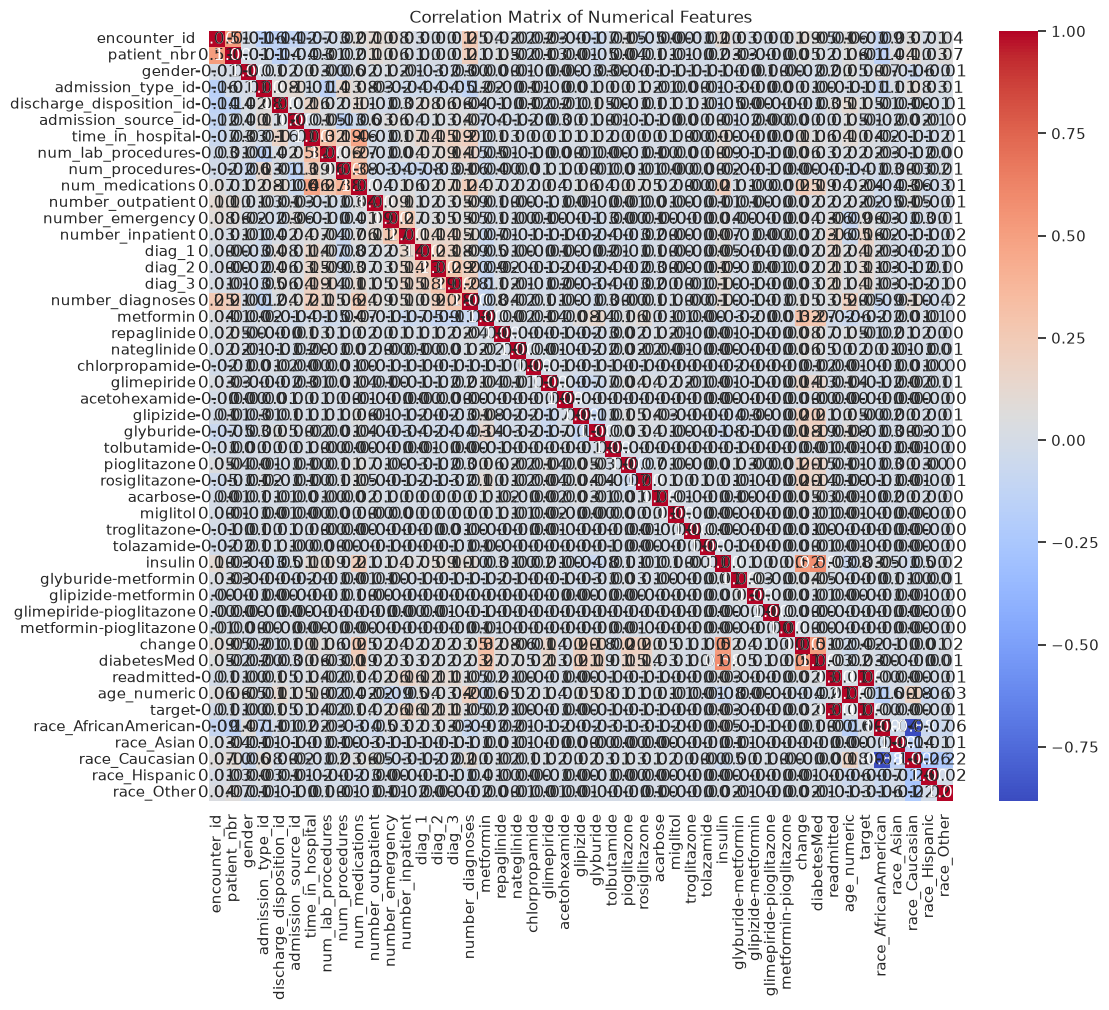

In [18]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [19]:
df.head()

,encounter_id,patient_nbr,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,change,diabetesMed,readmitted,age_numeric,target,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other
1,149190,55629189,1,[10-20),1,1,7,3,59,0,...,1,1,0,1,0,0,0,1,0,0
2,64410,86047875,1,[20-30),1,1,7,2,11,5,...,0,1,0,2,0,1,0,0,0,0
3,500364,82442376,0,[30-40),1,1,7,2,44,1,...,1,1,0,3,0,0,0,1,0,0
4,16680,42519267,0,[40-50),1,1,7,1,51,0,...,1,1,0,4,0,0,0,1,0,0
5,35754,82637451,0,[50-60),2,1,2,3,31,6,...,0,1,0,5,0,0,0,1,0,0
